In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, random, shutil, zipfile
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import AUC

zip_path = "/content/drive/MyDrive/dataset/driver-drowsiness-dataset-ddd.zip"
extract_path = "/content/dataset"
dataset_path = "/content/dataset/Driver Drowsiness Dataset (DDD)"
expanded_path = "/content/dataset_6000/Driver Drowsiness Dataset (DDD)"
classes = ['Drowsy', 'Non Drowsy']
num_target = 6000

if not os.path.exists(dataset_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
print(" تم فك الضغط بنجاح.")

 تم فك الضغط بنجاح.


In [ ]:
os.makedirs(expanded_path, exist_ok=True)
for cls in classes:
    src = os.path.join(dataset_path, cls)
    dst = os.path.join(expanded_path, cls)
    os.makedirs(dst, exist_ok=True)

    all_imgs = os.listdir(src)
    for i in range(num_target):
        img_name = random.choice(all_imgs)
        shutil.copy(os.path.join(src, img_name), os.path.join(dst, f"{i}_{img_name}"))
print(" تم إنشاء نسخة موسعة بـ6000 صورة لكل فئة.")

 تم إنشاء نسخة موسعة بـ6000 صورة لكل فئة.


In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

train_data = datagen.flow_from_directory(
    expanded_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    expanded_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 9600 images belonging to 2 classes.
Found 2400 images belonging to 2 classes.


In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[:-80]:
    layer.trainable = False
for layer in base_model.layers[-80:]:
    layer.trainable = True
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
)


callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
    ModelCheckpoint("/content/drive/MyDrive/ourprojectmodel.keras",
                    save_best_only=True, monitor='val_accuracy', mode='max')
]


In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

print(" تم تدريب النموذج")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 251s 711ms/step - accuracy: 0.5844 - auc: 0.6077 - loss: 0.6784 - val_accuracy: 0.6125 - val_auc: 0.6859 - val_loss: 0.6598 - learning_rate: 1.0000e-05
Epoch 2/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 203s 675ms/step - accuracy: 0.7117 - auc: 0.7855 - loss: 0.5560 - val_accuracy: 0.6975 - val_auc: 0.8584 - val_loss: 0.6064 - learning_rate: 1.0000e-05
Epoch 3/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 203s 676ms/step - accuracy: 0.7990 - auc: 0.8816 - loss: 0.4287 - val_accuracy: 0.8292 - val_auc: 0.9236 - val_loss: 0.3707 - learning_rate: 1.0000e-05
Epoch 4/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 212s 705ms/step - accuracy: 0.8507 - auc: 0.9249 - loss: 0.3481 - val_accuracy: 0.8083 - val_auc: 0.9583 - val_loss: 0.3878 - learning_rate: 1.0000e-05
Epoch 5/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 200s 667ms/step - accuracy: 0.8813 - auc: 0.9493 - loss: 0.2865 - val_accuracy: 0.7917 - val_auc: 0.9245 - val_loss: 0.4868 - learning_rate: 1.0000e-05
Epoch 6/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 

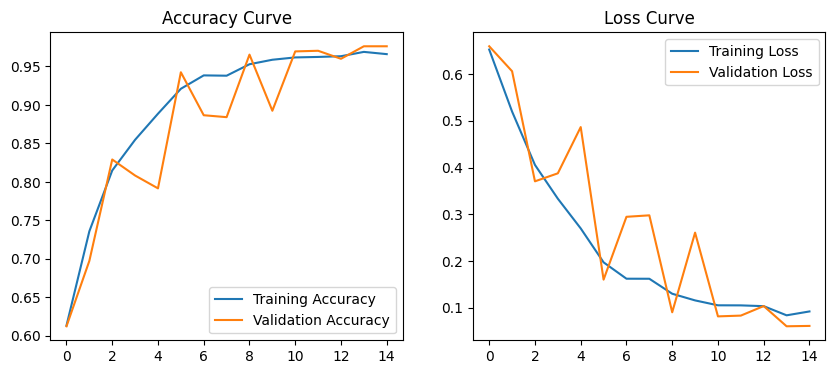

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# رسم منحنى الدقة
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.legend()

# رسم منحنى الخسارة
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.legend()

plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model

# تحميل النموذج القديم
model = load_model("/content/drive/MyDrive/ourprojectmodel.keras")

print("تم تحميل النموذج بنجاح")

# حفظه باسم جديد
model.save("/content/drive/MyDrive/ourfinalmodel.keras", save_format="keras")

print("تم حفظ النموذج الجديد بنجاح")


تم تحميل النموذج بنجاح
تم حفظ النموذج الجديد بنجاح


In [ ]:
# ============================================================
#    مقاييس نحسبهم
# ============================================================

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# ----------- 1) تحميل النموذج الصحيح -----------
model = load_model("/content/drive/MyDrive/ourfinalmodel.keras")
print(" تم تحميل النموذج الصحيح (ourfinalmodel.keras)")


# ----------- 2) تجهيز بيانات التحقق -----------
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

expanded_path = "/content/dataset_6000/Driver Drowsiness Dataset (DDD)"

val_data = datagen.flow_from_directory(
    expanded_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

print("تم تجهيز بيانات التحقق")


# ----------- 3) استخراج التنبؤات -----------
y_pred_prob = model.predict(val_data)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

y_true = val_data.labels


# ----------- 4) حساب المقاييس -----------
accuracy = accuracy_score(y_true, y_pred) * 100
precision = precision_score(y_true, y_pred) * 100
recall = recall_score(y_true, y_pred) * 100
f1 = f1_score(y_true, y_pred) * 100


# ----------- 5) طباعة النتائج -----------
print("\n النتائج النهائية (SKLEARN):")
print(f"Accuracy:  {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall:    {recall:.2f}%")
print(f"F1-score:  {f1:.2f}%")

print("\n انتهى الحساب بنجاح")



 تم تحميل النموذج الصحيح (ourfinalmodel.keras)
Found 4799 images belonging to 2 classes.
تم تجهيز بيانات التحقق


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


150/150 ━━━━━━━━━━━━━━━━━━━━ 25s 144ms/step

 النتائج النهائية (SKLEARN):
Accuracy:  99.77%
Precision: 99.63%
Recall:    99.92%
F1-score:  99.77%

 انتهى الحساب بنجاح


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=['Non-Drowsy', 'Drowsy']))


              precision    recall  f1-score   support

  Non-Drowsy       1.00      1.00      1.00      2399
      Drowsy       1.00      1.00      1.00      2400

    accuracy                           1.00      4799
   macro avg       1.00      1.00      1.00      4799
weighted avg       1.00      1.00      1.00      4799



In [ ]:
print(len(val_data.labels))


4799


Saving tired-driving.jpg to tired-driving.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


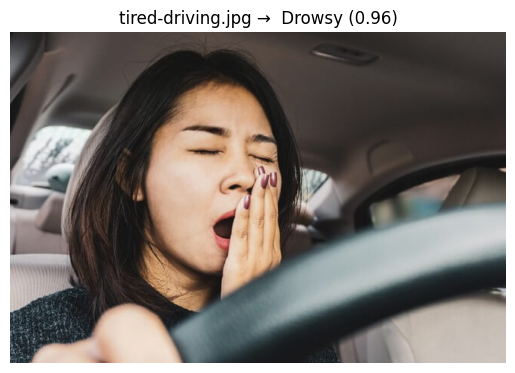

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model


# رفع الصور من الجهاز
uploaded = files.upload()

# المرور على كل صورة مرفوعة
for img_name in uploaded.keys():
    # قراءة الصورة
    img = cv2.imread(img_name)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    # التنبؤ
    prediction = model.predict(img_input)[0][0]
    label = " Drowsy" if prediction > 0.5 else " Awake"

    # عرض النتيجة
    plt.imshow(img_rgb)
    plt.title(f"{img_name} → {label} ({prediction:.2f})")
    plt.axis("off")
    plt.show()

Saving images.jpeg to images.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


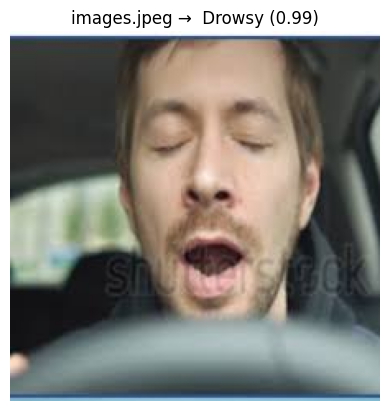

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model


# رفع الصور من الجهاز
uploaded = files.upload()

# المرور على كل صورة مرفوعة
for img_name in uploaded.keys():
    # قراءة الصورة
    img = cv2.imread(img_name)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    # التنبؤ
    prediction = model.predict(img_input)[0][0]
    label = " Drowsy" if prediction > 0.5 else " Awake"

    # عرض النتيجة
    plt.imshow(img_rgb)
    plt.title(f"{img_name} → {label} ({prediction:.2f})")
    plt.axis("off")
    plt.show()

Saving awak.jpg to awak.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


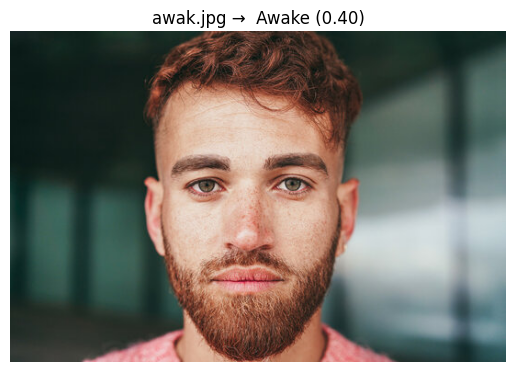

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model


# رفع الصور من الجهاز
uploaded = files.upload()

# المرور على كل صورة مرفوعة
for img_name in uploaded.keys():
    # قراءة الصورة
    img = cv2.imread(img_name)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    # التنبؤ
    prediction = model.predict(img_input)[0][0]
    label = " Drowsy" if prediction > 0.5 else " Awake"

    # عرض النتيجة
    plt.imshow(img_rgb)
    plt.title(f"{img_name} → {label} ({prediction:.2f})")
    plt.axis("off")
    plt.show()

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/ourfinalmodel.keras")
print("تم تحميل النموذج بنجاح")


تم تحميل النموذج بنجاح


In [ ]:
from google.colab import output
from IPython.display import Javascript, display
from base64 import b64decode
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ======  التقاط=====
def take_photo(filename='cam.jpg'):
    js = Javascript('''
      async function takePhoto() {
        const div = document.createElement('div');
        const video = document.createElement('video');
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();


        await new Promise(resolve => setTimeout(resolve, 1500));

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getVideoTracks()[0].stop();
        div.remove();

        const data = canvas.toDataURL('image/jpeg');
        google.colab.kernel.invokeFunction('notebook.TakePhoto', [data], {});
      }

      takePhoto();
    ''')

    display(js)

# ======  تسجيل وظيفة التخزين ======
def save_photo(data, filename='cam.jpg'):
    header, encoded = data.split(',', 1)
    img = b64decode(encoded)
    with open(filename, 'wb') as f:
        f.write(img)
    print("✔ تم حفظ الصورة:", filename)

output.register_callback('notebook.TakePhoto', save_photo)

# ======  التقاط الصورة ======
take_photo()


<IPython.core.display.Javascript object>

✔ تم حفظ الصورة: cam.jpg


Saving tired-driving.jpg to tired-driving.jpg


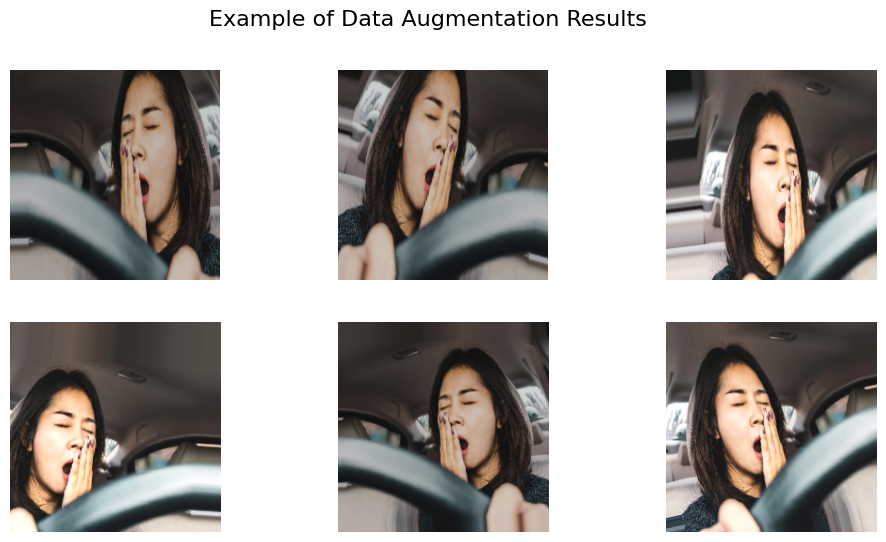

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import matplotlib.pyplot as plt
import numpy as np


from google.colab import files
uploaded = files.upload()

img_name = list(uploaded.keys())[0]

img = load_img(img_name, target_size=(224, 224))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

plt.figure(figsize=(12, 6))

i = 1
for batch in datagen.flow(img_array, batch_size=1):
    plt.subplot(2, 3, i)
    plt.imshow(batch[0].astype('uint8'))
    plt.axis("off")
    i += 1
    if i > 6:
        break

plt.suptitle("Example of Data Augmentation Results", fontsize=16)
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/ourfinalmodel.keras")
print("تم تحميل النموذج بنجاح")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
تم تحميل النموذج بنجاح


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


75/75 ━━━━━━━━━━━━━━━━━━━━ 46s 502ms/step


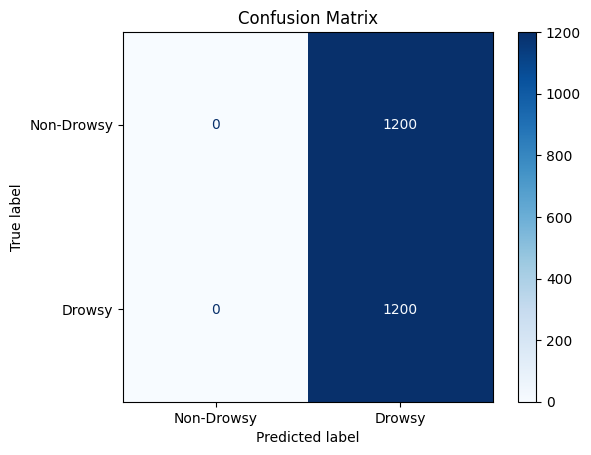

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_prob = model.predict(val_data)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = val_data.labels

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Drowsy', 'Drowsy'])
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔ الداتا موجودة جاهزة
Found 8358 images belonging to 2 classes.
✔ تم تجهيز بيانات التحقق
✔ تم تحميل النموذج بنجاح


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


262/262 ━━━━━━━━━━━━━━━━━━━━ 40s 140ms/step


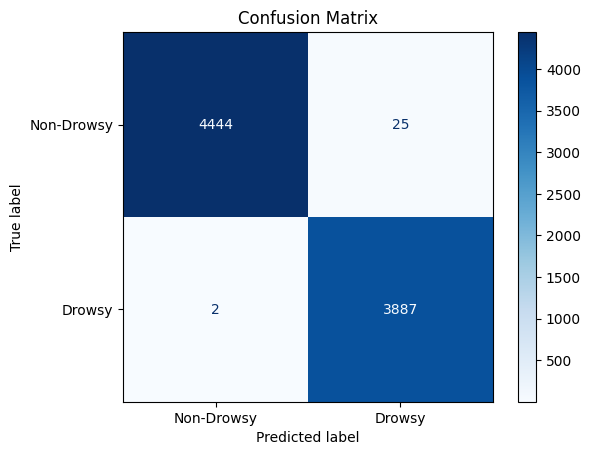

✔ تم عرض مصفوفة الارتباك بنجاح


In [ ]:
# ============================
# 1) Mount Google Drive
# ============================
from google.colab import drive
drive.mount('/content/drive')

# ============================
# 2) Prepare original dataset (NO expansion)
# ============================
import zipfile, os

zip_path = "/content/drive/MyDrive/dataset/driver-drowsiness-dataset-ddd.zip"
extract_path = "/content/dataset"
dataset_path = "/content/dataset/Driver Drowsiness Dataset (DDD)"

# فحص وجود الداتا — إذا انمسحت يرجّع يفك الضغط
if not os.path.exists(dataset_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print(" تم فك الضغط عن الداتا")
else:
    print(" الداتا موجودة جاهزة")

# ============================
# 3) Create validation dataset loader
# ============================
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

print(" تم تجهيز بيانات التحقق")

# ============================
# 4) Load trained model
# ============================
from tensorflow.keras.models import load_model

model_path = "/content/drive/MyDrive/ourfinalmodel.keras"
model = load_model(model_path)

print(" تم تحميل النموذج بنجاح")

# ============================
# 5) Confusion Matrix
# ============================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# التنبؤات
y_pred_prob = model.predict(val_data)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = val_data.labels

# حساب المصفوفة
cm = confusion_matrix(y_true, y_pred)

# عرضها
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Drowsy', 'Drowsy'])
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

print("✔ تم عرض مصفوفة الارتباك بنجاح")


262/262 ━━━━━━━━━━━━━━━━━━━━ 39s 149ms/step


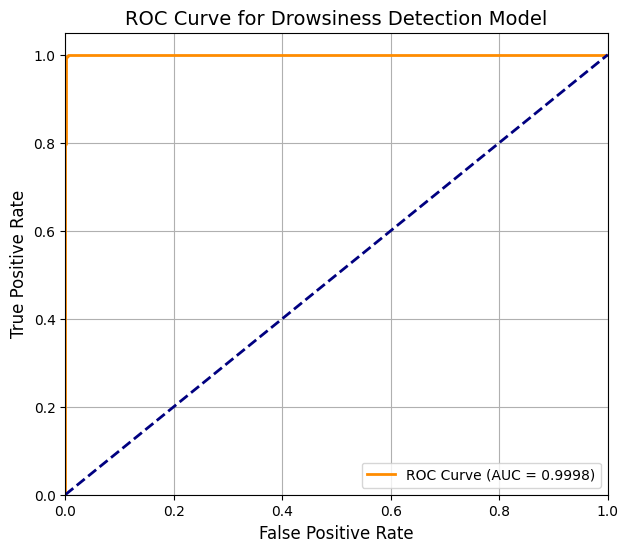

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

y_pred_prob = model.predict(val_data).ravel()
y_true = val_data.labels

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='ROC Curve (AUC = %0.4f)' % roc_auc)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve for Drowsiness Detection Model', fontsize=14)

plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import output
from IPython.display import Javascript, display
from base64 import b64decode
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ======  التقاط=====
def take_photo(filename='cam.jpg'):
    js = Javascript('''
      async function takePhoto() {
        const div = document.createElement('div');
        const video = document.createElement('video');
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();


        await new Promise(resolve => setTimeout(resolve, 1500));

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getVideoTracks()[0].stop();
        div.remove();

        const data = canvas.toDataURL('image/jpeg');
        google.colab.kernel.invokeFunction('notebook.TakePhoto', [data], {});
      }

      takePhoto();
    ''')

    display(js)

# ======  تسجيل وظيفة التخزين ======
def save_photo(data, filename='cam.jpg'):
    header, encoded = data.split(',', 1)
    img = b64decode(encoded)
    with open(filename, 'wb') as f:
        f.write(img)
    print(" تم حفظ الصورة:", filename)

output.register_callback('notebook.TakePhoto', save_photo)

# ======  التقاط الصورة ======
take_photo()


<IPython.core.display.Javascript object>

 تم حفظ الصورة: cam.jpg


In [ ]:
from google.colab import output
from IPython.display import Javascript, display
from base64 import b64decode
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ======  التقاط=====
def take_photo(filename='cam.jpg'):
    js = Javascript('''
      async function takePhoto() {
        const div = document.createElement('div');
        const video = document.createElement('video');
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();


        await new Promise(resolve => setTimeout(resolve, 1500));

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getVideoTracks()[0].stop();
        div.remove();

        const data = canvas.toDataURL('image/jpeg');
        google.colab.kernel.invokeFunction('notebook.TakePhoto', [data], {});
      }

      takePhoto();
    ''')

    display(js)

# ======  تسجيل وظيفة التخزين ======
def save_photo(data, filename='cam.jpg'):
    header, encoded = data.split(',', 1)
    img = b64decode(encoded)
    with open(filename, 'wb') as f:
        f.write(img)
    print(" تم حفظ الصورة:", filename)

output.register_callback('notebook.TakePhoto', save_photo)

# ======  التقاط الصورة ======
take_photo()


<IPython.core.display.Javascript object>

 تم حفظ الصورة: cam.jpg


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
